In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("DDoS Attack Dataset.csv")

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Display columns
print(df.columns)

Index(['Flow ID', 'Source IP', 'Source Port', 'Destination IP',
       'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration',
       'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
  

In [2]:
# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Remove invalid timestamps
df = df.dropna(subset=['Timestamp'])

print(df[['Timestamp','Label']].head())

            Timestamp   Label
0 2017-07-07 03:30:00  BENIGN
1 2017-07-07 03:30:00  BENIGN
2 2017-07-07 03:30:00  BENIGN
3 2017-07-07 03:30:00  BENIGN
4 2017-07-07 03:30:00  BENIGN


In [3]:
# Create binary attack column
df['Attack'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Set Timestamp as index
df.set_index('Timestamp', inplace=True)

# Count attacks every minute
attack_series = df['Attack'].resample('1min').sum()

print(attack_series.head())

Timestamp
2017-07-07 03:30:00    0
2017-07-07 03:31:00    0
2017-07-07 03:32:00    0
2017-07-07 03:33:00    0
2017-07-07 03:34:00    0
Freq: min, Name: Attack, dtype: int64


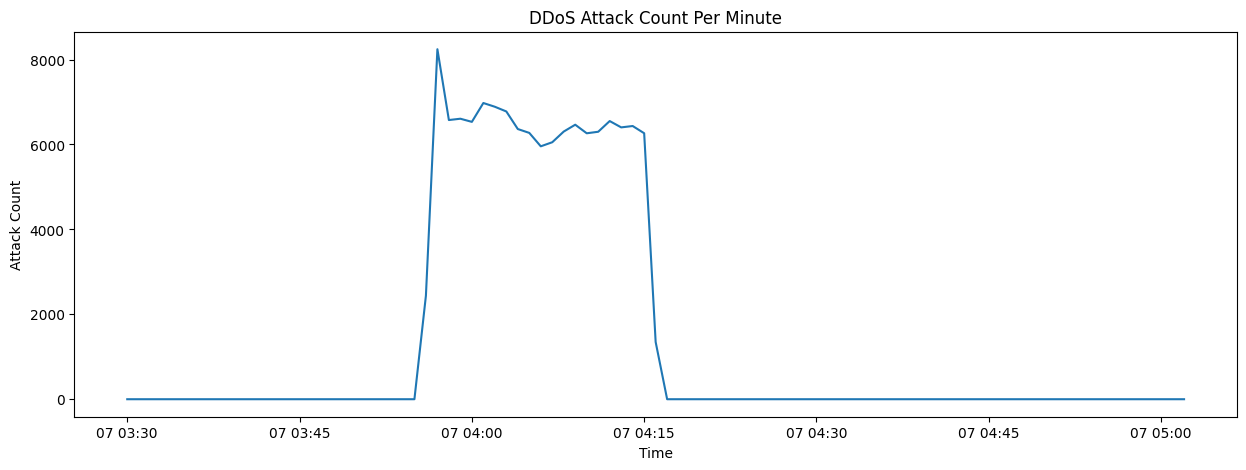

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(attack_series)
plt.title("DDoS Attack Count Per Minute")
plt.xlabel("Time")
plt.ylabel("Attack Count")
plt.show()

In [11]:
print(train.head(20))
print(train.describe())

print("Length:", len(train))
print("Missing values:", train.isnull().sum())
print("Unique values:", train.nunique())
print("Zero values:", (train == 0).sum())

Timestamp
2017-07-07 03:30:00    0
2017-07-07 03:31:00    0
2017-07-07 03:32:00    0
2017-07-07 03:33:00    0
2017-07-07 03:34:00    0
2017-07-07 03:35:00    0
2017-07-07 03:36:00    0
2017-07-07 03:37:00    0
2017-07-07 03:38:00    0
2017-07-07 03:39:00    0
2017-07-07 03:40:00    0
2017-07-07 03:41:00    0
2017-07-07 03:42:00    0
2017-07-07 03:43:00    0
2017-07-07 03:44:00    0
2017-07-07 03:45:00    0
2017-07-07 03:46:00    0
2017-07-07 03:47:00    0
2017-07-07 03:48:00    0
2017-07-07 03:49:00    0
Freq: min, Name: Attack, dtype: int64
count      33.000000
mean     1341.333333
std      2740.026034
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      8244.000000
Name: Attack, dtype: float64
Length: 33
Missing values: 0
Unique values: 8
Zero values: 26


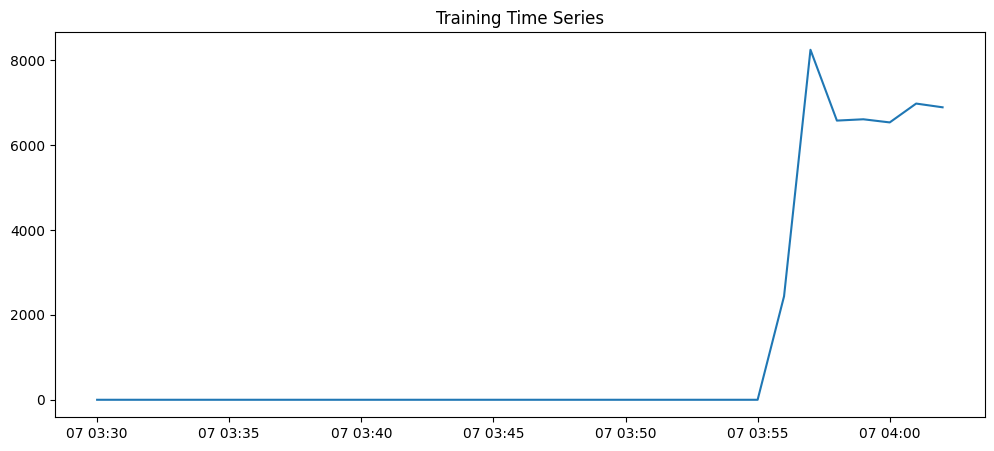

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(train)
plt.title("Training Time Series")
plt.show()

In [12]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 Attack   No. Observations:                   33
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -270.687
Date:                Mon, 03 Aug 2026   AIC                            553.375
Time:                        22:20:42   BIC                            562.169
Sample:                    07-07-2017   HQIC                           556.290
                         - 07-07-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1103      0.182      0.607      0.544      -0.246       0.466
ar.L2         -0.0896      0.439     -0.204      0.838      -0.949       0.770
ar.L3         -0.0112      0.969     -0.012      0.9

c:\Users\ABHISHEK M B\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\stattools.py:1431: RuntimeWarning: divide by zero encountered in divide
  test_statistic = numer_squared_sum / denom_squared_sum


In [7]:
forecast = model_fit.forecast(steps=60)

print(forecast)

2017-07-07 04:03:00    6842.924118
2017-07-07 04:04:00    6837.000901
2017-07-07 04:05:00    6863.939869
2017-07-07 04:06:00    6863.238125
2017-07-07 04:07:00    6858.539113
2017-07-07 04:08:00    6857.511308
2017-07-07 04:09:00    6859.191617
2017-07-07 04:10:00    6859.469606
2017-07-07 04:11:00    6859.124208
2017-07-07 04:12:00    6858.993357
2017-07-07 04:13:00    6859.092295
2017-07-07 04:14:00    6859.131810
2017-07-07 04:15:00    6859.111145
2017-07-07 04:16:00    6859.097818
2017-07-07 04:17:00    6859.102838
2017-07-07 04:18:00    6859.106752
2017-07-07 04:19:00    6859.105815
2017-07-07 04:20:00    6859.104644
2017-07-07 04:21:00    6859.104817
2017-07-07 04:22:00    6859.105146
2017-07-07 04:23:00    6859.105130
2017-07-07 04:24:00    6859.105038
2017-07-07 04:25:00    6859.105036
2017-07-07 04:26:00    6859.105060
2017-07-07 04:27:00    6859.105063
2017-07-07 04:28:00    6859.105057
2017-07-07 04:29:00    6859.105055
2017-07-07 04:30:00    6859.105057
2017-07-07 04:31:00 

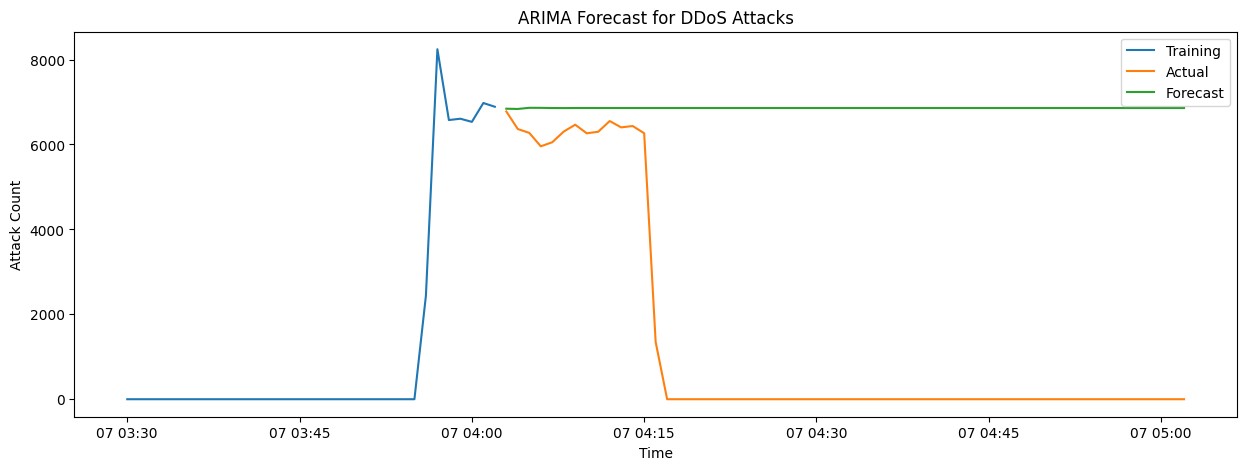

In [8]:
plt.figure(figsize=(15,5))

plt.plot(train.index, train, label='Training')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast')

plt.title("ARIMA Forecast for DDoS Attacks")
plt.xlabel("Time")
plt.ylabel("Attack Count")
plt.legend()

plt.show()

In [9]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, forecast))
print("RMSE:", rmse)

RMSE: 6053.316617948556


In [10]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 5462.53662705716
RMSE: 6053.316617948556
MAPE: 2.368284159547774e+19
